# Asgmt4: Text Clustering and Classification


## Load your data (for public sharing)

In [1]:
import gdown
import pandas as pd

# 명진님의 파일 ID로 설정됨
file_id = '1vFZmn-8XZzZl9b2Y9z5UbdjAXZHMO7aE'

# 코랩 환경에 저장될 파일 이름
output_filename = 'filtered_reddit_data.xlsx'

# 구글 드라이브에서 다운로드 (직접 다운로드 링크 생성)
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, output_filename, quiet=False)

print(f"File '{output_filename}' downloaded successfully!")

# 엑셀 파일이므로 read_excel 사용
df_raw = pd.read_excel(output_filename)

# 데이터 상위 5개 행 확인
display(df_raw.head())

Downloading...
From: https://drive.google.com/uc?id=1vFZmn-8XZzZl9b2Y9z5UbdjAXZHMO7aE
To: /content/filtered_reddit_data.xlsx
100%|██████████| 10.4M/10.4M [00:00<00:00, 123MB/s]


File 'filtered_reddit_data.xlsx' downloaded successfully!


,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
0,k857c4c,3,Would you be able to post links to the indepen...,IsraelPalestine,2023-11-06 23:59:00,17p73rm,Alive_Collection_454,0,3,0,...,20,924,944,62,My buddy and I were discussing over the situat...,Is Hamas lying when releasing numbers of fatal...,0.74,62,0,2023-11-06 16:50:00
1,k857b4l,13,Of course it's important. Until the 20th centu...,IsraelPalestine,2023-11-06 23:59:00,17pdtfd,kawaii_war_dandy,0,13,0,...,685,8579,9264,57,I just read in the [New York Times](https://ww...,How does the Al Shifa hospital house 60 000 pe...,0.85,57,0,2023-11-06 21:36:00
2,k857amm,1,"ISW, the conservative think tank representing ...",IsraelPalestine,2023-11-06 23:59:00,17p76sb,Having_A_Day,0,1,0,...,3,3052,3055,31,Now that the IDF has boots on the ground in Ga...,Public Reaction to Ground Footage,0.82,31,0,2023-11-06 16:54:00
3,k8579mi,1,###[View link](https://rapidsave.com/info?url=...,NonCredibleDefense,2023-11-06 23:59:00,17obtsm,SaveVideo,0,1,0,...,15073,641575,656648,1433,NaN,Hamas Air Support in a nutshell,0.96,1433,0,2023-11-05 13:21:00
4,k8578wh,14,I find it extremely unlikely that these specia...,CombatFootage,2023-11-06 23:59:00,17p7mfx,what-the-puck,0,14,0,...,1095,166322,169946,11536,NaN,Better footage of the israeli special forces a...,0.94,11536,0,2023-11-06 17:12:00


In [2]:
import string
import re

def clean_text(text):
  text = str(text)

  # Step 1: Lowercase
  text = text.lower()

  # Step 2: Use remove_punct to remove punctuation marks
  text = text.translate(str.maketrans('', '', string.punctuation))

  # Step 3: Remove URL
  text = re.sub(r'http\S+', '', text)

  # Step 4: Remove extra whitespace characters
  text = " ".join(text.split())

  return text.strip()

  # Apply the cleaning function to your text column of the DataFrame
text_column = 'self_text'
clean_text_column = 'cleaned_text'

df_raw[clean_text_column] = df_raw[text_column].apply(
    lambda x: clean_text(x)
)

display(df_raw[[text_column, clean_text_column]].head())


,self_text,cleaned_text
0,Would you be able to post links to the indepen...,would you be able to post links to the indepen...
1,Of course it's important. Until the 20th centu...,of course its important until the 20th century...
2,"ISW, the conservative think tank representing ...",isw the conservative think tank representing u...
3,###[View link](https://rapidsave.com/info?url=...,view link info feedback for savevideoamp32amp3...
4,I find it extremely unlikely that these specia...,i find it extremely unlikely that these specia...


---
# Part A. Unsupervised: Clustering & Topic Modeling

In this part, you will discover structure in your corpus without using any label. Try multiple methods on the same data and reflect on what each one reveals (and hides).

## Q1: KMeans clustering on TF-IDF

- 1.1 Build a TF-IDF matrix of your cleaned text.

- 1.2 Choose `k` using diagnostics
    - Fit `KMeans` for a range of `k` (e.g., `k = 2 .. 10`).
    - Plot the **elbow curve** (inertia) and **silhouette scores**.
    - Pick a `k` that is supported by the diagnostics *and* makes sense for your data.
- 1.3 Fit final KMeans with your chosen `k`. For each cluster:
    - Show the cluster size and the **top 10 words** (from `kmeans.cluster_centers_`).
    - Print 2–3 **representative documents** (highest cluster strength).
    - If your data has a known categorical variable (sentiment, source, year, topic label), produce a `pd.crosstab(cluster, group)` to see whether clusters align with it.


In [9]:
# 1.1 TF-IDF matrix


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# 데이터 로드
df_raw = pd.read_excel('/content/filtered_reddit_data.csv.xlsx')
df_raw['self_text'] = df_raw['self_text'].fillna('').astype(str)
clean_text_column = 'self_text'

# ── 1.1 TF-IDF matrix ───────────────────────────────────────────────────────

vectorizer = TfidfVectorizer(max_df=0.9, min_df=5, stop_words='english')
X_tfidf = vectorizer.fit_transform(df_raw[clean_text_column])
feature_names = vectorizer.get_feature_names_out()
print(f"TF-IDF Matrix shape: {X_tfidf.shape}")

TF-IDF Matrix shape: (46290, 10132)


k=2 | inertia=44927 | silhouette=0.0073
k=3 | inertia=44774 | silhouette=0.0068
k=4 | inertia=44711 | silhouette=0.0076
k=5 | inertia=44580 | silhouette=0.0090
k=6 | inertia=44471 | silhouette=0.0085
k=7 | inertia=44414 | silhouette=0.0093
k=8 | inertia=44348 | silhouette=0.0092
k=9 | inertia=44261 | silhouette=0.0107
k=10 | inertia=44207 | silhouette=0.0101


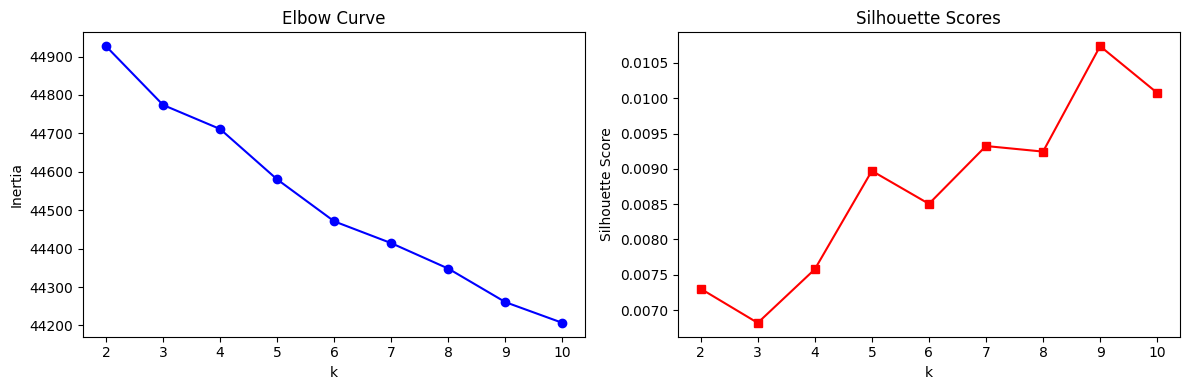


Chosen k = 9


In [11]:
# 1.2 Choose k (elbow + silhouette)

inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_tfidf)
    inertias.append(km.inertia_)
    idx = np.random.choice(X_tfidf.shape[0], size=3000, replace=False)
    sil = silhouette_score(X_tfidf[idx], km.labels_[idx], random_state=42)
    sil_scores.append(sil)
    print(f"k={k} | inertia={km.inertia_:.0f} | silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve'); axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), sil_scores, 'rs-')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores'); axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('Q1_2_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nChosen k = {best_k}")


Cluster 0 | size=830
  Top 10 words: ['good', 'luck', 'like', 'people', 'just', 'bad', 'point', 'thing', 'job', 'pretty']
  Representative docs:
    - So good
    - Good.

Cluster 1 | size=3041
  Top 10 words: ['hamas', 'israel', 'civilians', 'gaza', 'palestinians', 'idf', 'people', 'just', 'did', 'terrorists']
  Representative docs:
    - Hamas must be purged
    - They own Hamas. That’s why. They are Hamas.

Cluster 2 | size=4265
  Top 10 words: ['just', 'don', 'know', 'think', 'want', 'really', 'right', 'shit', 'going', 'didn']
  Representative docs:
    - Just pirate it
    - Just an inchident

Cluster 3 | size=3379
  Top 10 words: ['israel', 'hamas', 'gaza', 'palestinians', 'war', 'people', 'palestine', 'just', 'civilians', 'support']
  Representative docs:
    - And Israel?
    - Israel

Cluster 4 | size=26758
  Top 10 words: ['war', 'did', 'right', 'lol', 'yes', 'video', 'time', 'think', 'shit', 'idf']
  Representative docs:
    - i think the man in the video is doing something

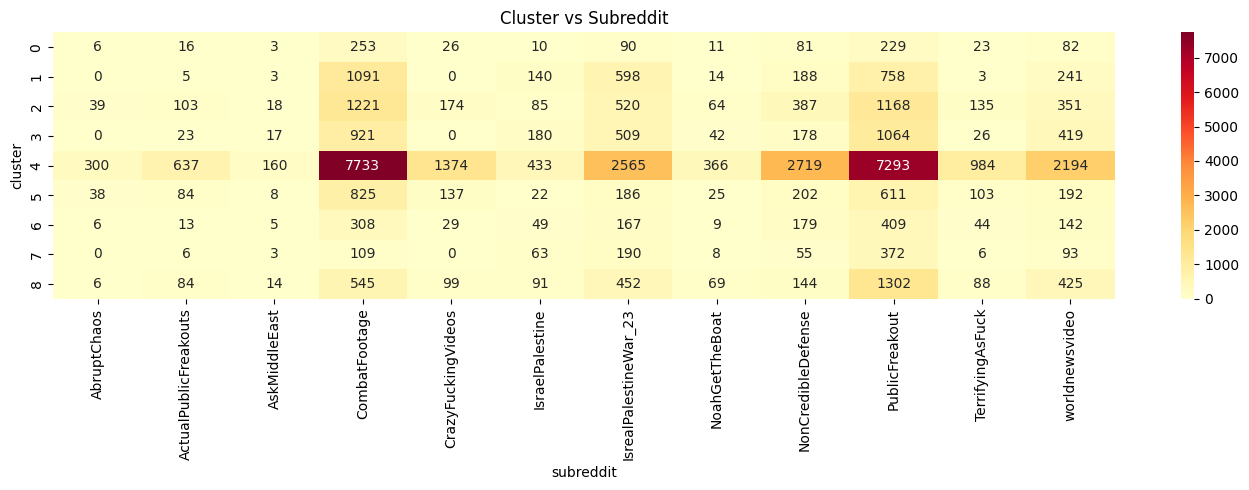

In [12]:
# 1.3 Final KMeans: top words, representative docs, crosstab


km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_final.fit(X_tfidf)
df_raw['cluster'] = km_final.labels_

for c in range(best_k):
    cluster_df = df_raw[df_raw['cluster'] == c]
    top_words = [feature_names[i] for i in km_final.cluster_centers_[c].argsort()[::-1][:10]]
    print(f"\nCluster {c} | size={len(cluster_df)}")
    print(f"  Top 10 words: {top_words}")

    idx = cluster_df.index.tolist()
    sims = cosine_similarity(X_tfidf[idx], km_final.cluster_centers_[c].reshape(1, -1)).flatten()
    top2 = np.argsort(sims)[::-1][:2]
    print("  Representative docs:")
    for pos in top2:
        print(f"    - {cluster_df.iloc[pos][clean_text_column][:120]}")

crosstab = pd.crosstab(df_raw['cluster'], df_raw['subreddit'])
print("\nCrosstab (cluster vs subreddit):")
print(crosstab)

plt.figure(figsize=(14, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Cluster vs Subreddit')
plt.tight_layout()
plt.savefig('Q1_3_crosstab_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


#사진을 보면 x축이 결국 레딧 게시판, 즉 어느 게시판에서 왔냐, 클러스터4sms combatfootage publocfreakout에서 온게 많다는거지
# pepresentation docs는 댓글 중에 대표 되는걸 말해

## Q2: HDBSCAN clustering

HDBSCAN does not require you to specify `k`, handles non-spherical clusters, and flags noise points as `-1`.

- 2.1 Reduce dimensions before clustering
    - Project the TF-IDF matrix (or sentence embeddings — your choice; justify) into ~5–10 dimensions with UMAP (`n_components=10`, `metric='cosine'`).

- 2.2 Fit HDBSCAN on the reduced features. Compare:
    - Number of clusters found
    - Percentage of noise points (label `-1`)
    - Cluster size distribution

- 2.3 For your chosen setting, inspect the clusters
    - Top words per cluster (mean TF-IDF over cluster members, skip the noise label)
    - 2–3 representative documents per cluster
    - If your data has a known categorical variable (sentiment, source, year, topic label), produce a `pd.crosstab(cluster, group)` to see whether clusters align with it.


In [13]:
!pip install umap-learn hdbscan

In [15]:
# 2.1 UMAP dimensionality reduction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import umap
import hdbscan

# 패키지 설치가 필요하면 아래 주석 해제 후 실행
# !pip install umap-learn hdbscan

# 데이터 로드 (Q1에서 이미 했으면 생략 가능)
df_raw = pd.read_excel('/content/filtered_reddit_data.csv.xlsx')
df_raw['self_text'] = df_raw['self_text'].fillna('').astype(str)
clean_text_column = 'self_text'

# TF-IDF (Q1에서 이미 했으면 생략 가능)
vectorizer = TfidfVectorizer(max_df=0.9, min_df=5, stop_words='english')
X_tfidf = vectorizer.fit_transform(df_raw[clean_text_column])
feature_names = vectorizer.get_feature_names_out()

# TF-IDF가 너무 커서(46290 x 10000+) HDBSCAN이 느림
# → UMAP으로 10차원으로 압축 (핵심 정보는 유지하면서 크기만 줄임)

reducer = umap.UMAP(n_components=10, metric='cosine', random_state=42)
X_umap = reducer.fit_transform(X_tfidf)
print(f"UMAP 결과 shape: {X_umap.shape}")  # (46290, 10)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 결과 shape: (46290, 10)


min_cluster_size=100 | 클러스터 수=91 | 노이즈=63.2%
min_cluster_size=200 | 클러스터 수=3 | 노이즈=0.9%
min_cluster_size=500 | 클러스터 수=2 | 노이즈=0.4%


/tmp/ipykernel_2946/2941377519.py:33: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/2941377519.py:33: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/2941377519.py:33: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/2941377519.py:33: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/2941377519.py:33: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/2941377519.py:33: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/2941377519.py:33: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_l

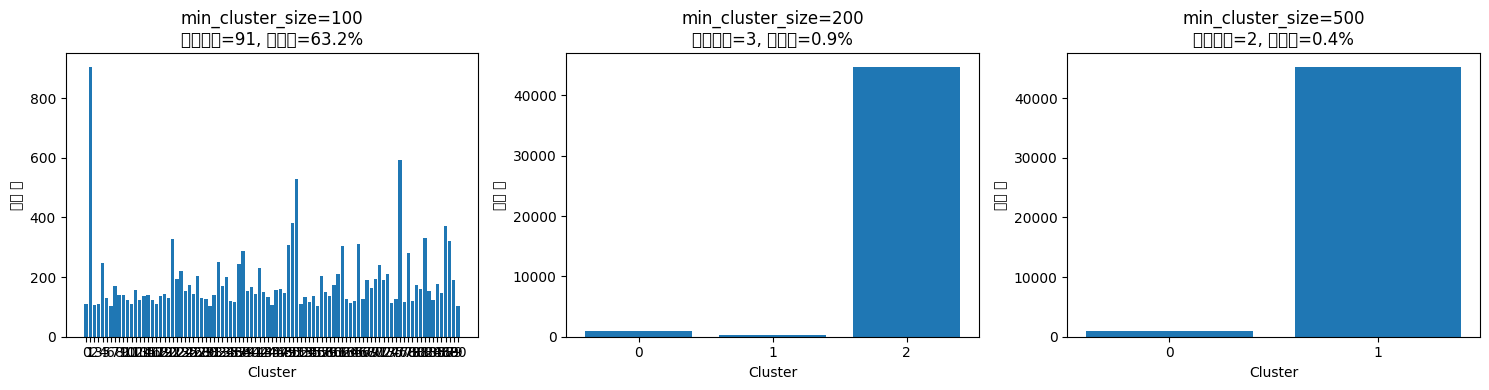


선택한 min_cluster_size = 200


In [16]:
# 2.2 HDBSCAN with multiple min_cluster_size values

# min_cluster_size = "최소 이 숫자 이상이어야 클러스터로 인정"
# 작을수록 클러스터 많아짐, 클수록 클러스터 적어짐

results = []
for size in [100, 200, 500]:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=size)
    labels = clusterer.fit_predict(X_umap)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1은 노이즈
    noise_pct = (labels == -1).sum() / len(labels) * 100

    results.append({'min_cluster_size': size,
                    'n_clusters': n_clusters,
                    'noise_pct': round(noise_pct, 1)})

    print(f"min_cluster_size={size} | 클러스터 수={n_clusters} | 노이즈={noise_pct:.1f}%")

# 클러스터 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, r in enumerate(results):
    size = r['min_cluster_size']
    clusterer = hdbscan.HDBSCAN(min_cluster_size=size)
    labels = clusterer.fit_predict(X_umap)
    counts = pd.Series(labels).value_counts().sort_index()
    counts = counts[counts.index != -1]  # 노이즈 제외
    axes[i].bar(counts.index.astype(str), counts.values)
    axes[i].set_title(f'min_cluster_size={size}\n클러스터={r["n_clusters"]}, 노이즈={r["noise_pct"]}%')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('문서 수')

plt.tight_layout()
plt.savefig('Q2_2_hdbscan_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 최적 설정 선택 (클러스터가 적당히 있고 노이즈가 너무 많지 않은 것)
best_size = 200
print(f"\n선택한 min_cluster_size = {best_size}")



# 왼쪽 (min_cluster_size=100)

# 클러스터가 91개나 나왔어요
# 노이즈가 63.2% → 절반 이상이 "어느 그룹에도 안 맞는다"고 튕겨나감
# 너무 잘게 쪼개져서 의미있는 분석이 어려워요 ❌

# 가운데 (min_cluster_size=200)

# 클러스터 3개, 노이즈 0.9%
# 클러스터 2번에 데이터가 몰려있긴 하지만
# 노이즈가 거의 없고 깔끔하게 나뉨 ✅ → 이걸 선택한 이유

# 오른쪽 (min_cluster_size=500)

# 클러스터 2개, 노이즈 0.4%
# 너무 크게 묶어버려서 세분화가 안 됨
# 클러스터 2개는 너무 적어요 ❌


최종 클러스터 수: 3 | 노이즈: 0.9%

Cluster 0 | size=905
  Top 10 words: ['00', 'الله', 'женевы', 'zoomed', '100000', '1000957953', '1000s', '100k', '100km', '100s']
  Representative docs:
    - It was
    - Mulligan

Cluster 1 | size=248
  Top 10 words: ['wikipedia', 'wiki', 'en', 'org', 'https', 'feature', 'shared', 'youtu', 'israel', 'jews']
  Representative docs:
    - 1: https://en.wikipedia.org/wiki/Jewish_secularism

2: https://en.wikipedia.org/wiki/Cultural_Zionism
    - What’s next, this?

https://en.m.wikipedia.org/wiki/Kristallnacht

Cluster 2 | size=44742
  Top 10 words: ['hamas', 'israel', 'people', 'just', 'like', 'don', 'think', 'know', 'war', 'gaza']
  Representative docs:
    - My guy - respectfully, you have fallen for the narrative.

You wrote a really long paragraph about Hamas. I’m not here t
    - I'm no expert but I can tell you a few things. Hamas is the elected governing body of the gaza strip part of palestine a

Crosstab (cluster vs subreddit):
subreddit  AbruptChaos  

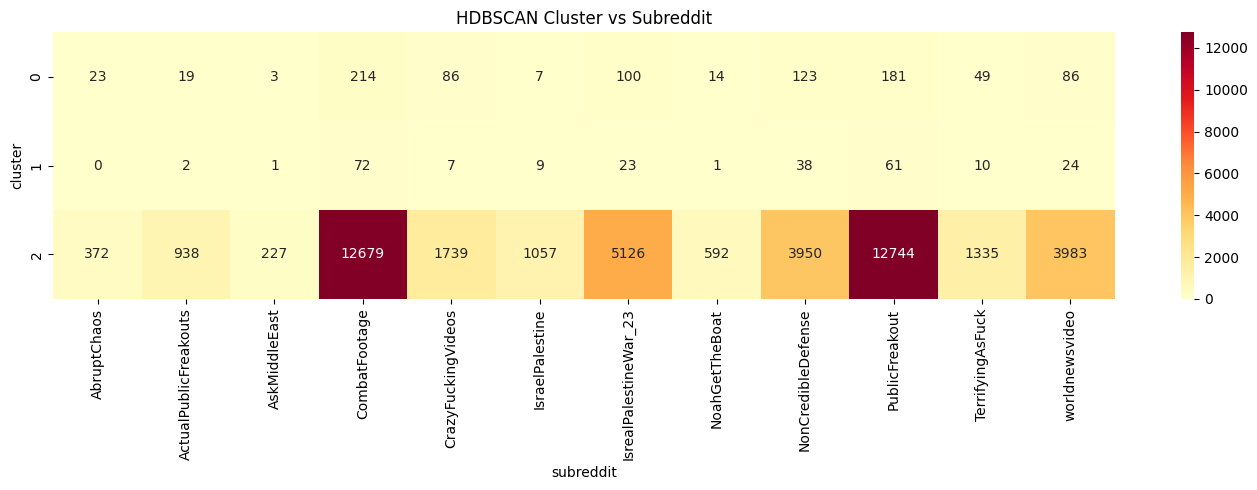

In [17]:
# 2.3 Inspect clusters: top words, representative docs, crosstab

# 최적 설정으로 최종 HDBSCAN 실행

final_clusterer = hdbscan.HDBSCAN(min_cluster_size=best_size)
final_labels = final_clusterer.fit_predict(X_umap)
df_raw['cluster'] = final_labels

n_clusters = len(set(final_labels)) - (1 if -1 in final_labels else 0)
noise_pct = (final_labels == -1).sum() / len(final_labels) * 100
print(f"최종 클러스터 수: {n_clusters} | 노이즈: {noise_pct:.1f}%")

# 클러스터별 top words + 대표 문서 출력
for c in sorted(set(final_labels)):
    if c == -1:
        continue  # 노이즈는 스킵

    cluster_df = df_raw[df_raw['cluster'] == c]

    # top words: 클러스터 내 문서들의 TF-IDF 평균
    cluster_idx = cluster_df.index.tolist()
    mean_tfidf = np.asarray(X_tfidf[cluster_idx].mean(axis=0)).flatten()
    top10_idx = mean_tfidf.argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top10_idx]

    print(f"\nCluster {c} | size={len(cluster_df)}")
    print(f"  Top 10 words: {top_words}")

    # 대표 문서: 클러스터 평균 벡터와 코사인 유사도 높은 문서 2개
    mean_vec = mean_tfidf.reshape(1, -1)
    sims = cosine_similarity(X_tfidf[cluster_idx], mean_vec).flatten()
    top2 = np.argsort(sims)[::-1][:2]
    print("  Representative docs:")
    for pos in top2:
        print(f"    - {cluster_df.iloc[pos][clean_text_column][:120]}")

# crosstab: cluster vs subreddit (노이즈 제외)
df_no_noise = df_raw[df_raw['cluster'] != -1]
crosstab = pd.crosstab(df_no_noise['cluster'], df_no_noise['subreddit'])
print("\nCrosstab (cluster vs subreddit):")
print(crosstab)

plt.figure(figsize=(14, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('HDBSCAN Cluster vs Subreddit')
plt.tight_layout()
plt.savefig('Q2_3_crosstab_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#Cluster 2 = 전쟁/충격 영상 게시판의 일반 댓글 (대다수)
# Cluster 0, 1 = 이스라엘-팔레스타인 토론 관련 소수 댓글

## Q3: Topic modeling — LDA 토픽찾는거지 CountVectorizer로 갯수 행렬세서

Clustering forces each document into one group. Topic models treat documents as **mixtures** of topics.

- 3.1 Build input
    - Build a `CountVectorizer` matrix (LDA expects raw counts, not TF-IDF).

- 3.2 Fit LDA on the count matrix.
    - Topic size distribution (dominant topic per document)
    - Topic strength (max topic probability per document)

- 3.3 For your chosen setting, inspect the topics
    - Top 10 words per topic (from `lda.components_`)
    - 2–3 representative documents per topic (highest topic strength)
    - If your data has a known categorical variable (sentiment, source, year, topic label), produce a `pd.crosstab(cluster, group)` to see whether clusters align with it.

Iterate 3.2 and 3.3 until you get `n_components` you like.


In [18]:
# 3.1 CountVectorizer matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 데이터 로드 (Q1에서 이미 했으면 생략 가능)
df_raw = pd.read_excel('/content/filtered_reddit_data.csv.xlsx')
df_raw['self_text'] = df_raw['self_text'].fillna('').astype(str)
clean_text_column = 'self_text'

# ── 3.1 CountVectorizer matrix ───────────────────────────────────────────────
# LDA는 TF-IDF 말고 단어 개수(raw count)를 써야 해요
# 이유: LDA는 내부적으로 확률 계산을 하기 때문

vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words='english')
X_count = vectorizer.fit_transform(df_raw[clean_text_column])
feature_names = vectorizer.get_feature_names_out()
print(f"Count Matrix shape: {X_count.shape}")

Count Matrix shape: (46290, 10132)


n_components=5 | perplexity=2553.9
n_components=7 | perplexity=2587.0
n_components=10 | perplexity=2655.1
n_components=15 | perplexity=2757.2


/tmp/ipykernel_2946/354235736.py:24: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/354235736.py:24: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/354235736.py:24: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/354235736.py:24: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/354235736.py:24: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/354235736.py:24: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/354235736.py:24: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

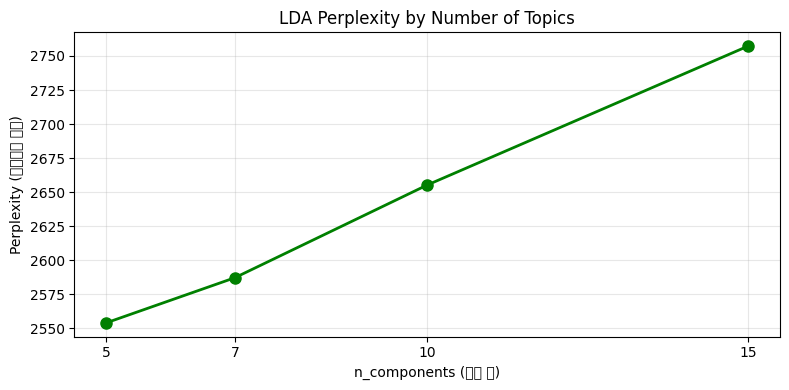


선택한 n_components = 5


In [19]:
# 3.2 Fit LDA (try multiple n_components)

# n_components = 몇 개의 주제로 나눌지
# perplexity = 낮을수록 모델이 데이터를 잘 설명함

perplexities = []
n_list = [5, 7, 10, 15]

for n in n_list:
    lda = LatentDirichletAllocation(n_components=n, random_state=42, max_iter=20)
    lda.fit(X_count)
    perp = lda.perplexity(X_count)
    perplexities.append(perp)
    print(f"n_components={n} | perplexity={perp:.1f}")

# perplexity 그래프
plt.figure(figsize=(8, 4))
plt.plot(n_list, perplexities, 'go-', linewidth=2, markersize=8)
plt.xlabel('n_components (주제 수)')
plt.ylabel('Perplexity (낮을수록 좋음)')
plt.title('LDA Perplexity by Number of Topics')
plt.xticks(n_list)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Q3_2_lda_perplexity.png', dpi=150, bbox_inches='tight')
plt.show()

# 최적 n_components 선택
best_n = n_list[np.argmin(perplexities)]
print(f"\n선택한 n_components = {best_n}")


Topic 0 | 문서 수=4600
  Top 10 words: ['https', 'com', 'amp', 'www', 'video', 'reddit', 'news', 'org', 'en', 'watch']
  Representative docs:
    - [0.99] High jacking top comment for news article link -  


[https://www.dw.com/en/turkey-terrorists-attack-interior-ministry-i
    - [0.99] I will be messaging you in 1 month on [**2023-11-28 09:09:03 UTC**](http://www.wolframalpha.com/input/?i=2023-11-28%2009

Topic 1 | 문서 수=12602
  Top 10 words: ['israel', 'hamas', 'people', 'palestinians', 'jews', 'palestine', 'just', 'war', 'palestinian', 'world']
  Representative docs:
    - [1.00] the issue is way more complicated then just hamas. Also No\_Touch is right about the media and driving devision.  


Tho
    - [0.99] This conflict is started 100% caused by isreal, and by Israel, I mean the zionist nazi regime, not the real jewish ppl.


Topic 2 | 문서 수=9004
  Top 10 words: ['hamas', 'israel', 'gaza', 'idf', 'civilians', 'war', 'military', 'civilian', 'like', 'just']
  Representative docs:
  

/tmp/ipykernel_2946/1105470825.py:34: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/1105470825.py:34: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/1105470825.py:34: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2946/1105470825.py:35: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.savefig('Q3_3_topic_distribution.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2946/1105470825.py:35: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.savefig('Q3_3_topic_distribution.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2946/1105470825.py:35: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.savefig('Q3_3_topic_distribution.png', dpi=15

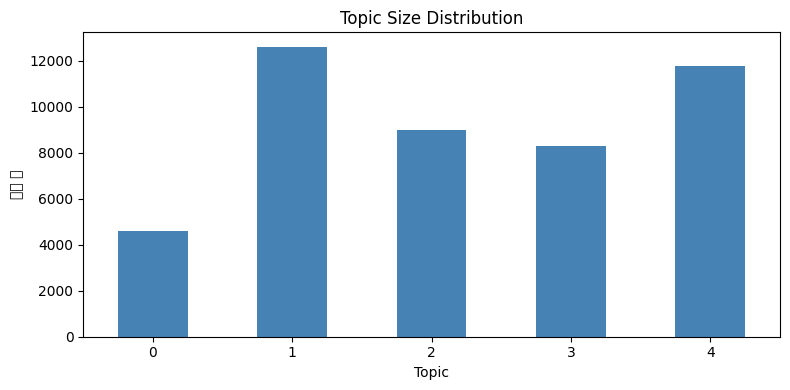


Topic Strength (max topic prob per doc):
count    46290.000000
mean         0.656254
std          0.175018
min          0.200000
25%          0.527056
50%          0.643693
75%          0.798297
max          0.996057
Name: topic_strength, dtype: float64

Crosstab (topic vs subreddit):
subreddit       AbruptChaos  ActualPublicFreakouts  AskMiddleEast  \
dominant_topic                                                      
0                        88                     93             21   
1                        13                    146             97   
2                        33                     49             26   
3                       137                    257             43   
4                       124                    426             44   

subreddit       CombatFootage  CrazyFuckingVideos  IsraelPalestine  \
dominant_topic                                                       
0                        1098                 272               83   
1                  

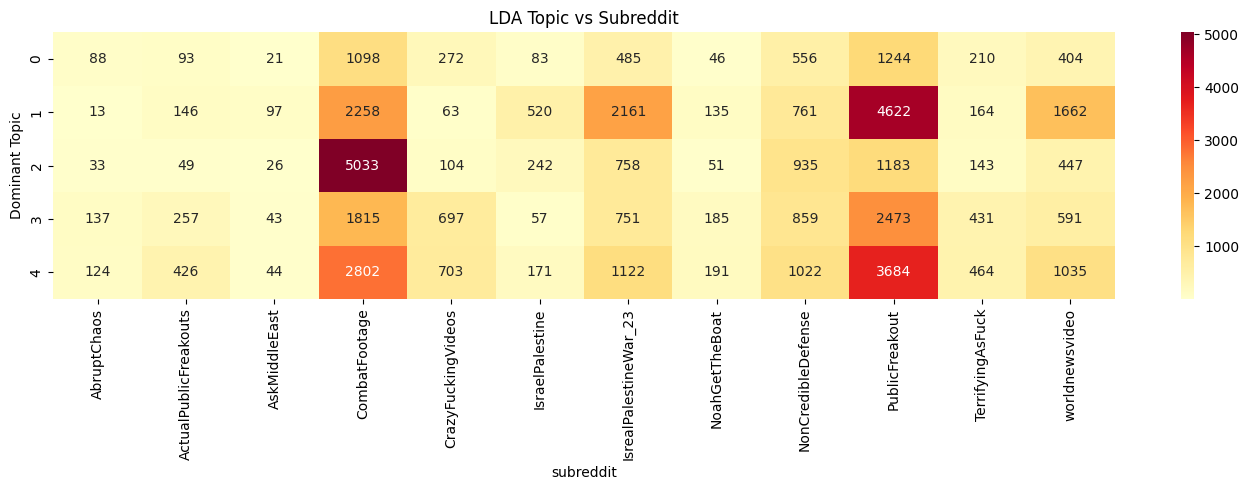

In [20]:
# 3.3 Inspect topics: top words, representative docs, crosstab

lda_final = LatentDirichletAllocation(n_components=best_n, random_state=42, max_iter=20)
doc_topic_matrix = lda_final.fit_transform(X_count)  # 각 문서의 주제별 확률

# 주제별 dominant topic (가장 확률 높은 주제)
df_raw['dominant_topic'] = doc_topic_matrix.argmax(axis=1)
# 주제 강도 (가장 높은 주제의 확률값)
df_raw['topic_strength'] = doc_topic_matrix.max(axis=1)

# 각 주제별 top words + 대표 문서
for topic_id in range(best_n):
    # top 10 words
    top10_idx = lda_final.components_[topic_id].argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top10_idx]

    topic_df = df_raw[df_raw['dominant_topic'] == topic_id]
    print(f"\nTopic {topic_id} | 문서 수={len(topic_df)}")
    print(f"  Top 10 words: {top_words}")

    # 대표 문서: topic_strength 높은 순 2개
    top2 = topic_df.nlargest(2, 'topic_strength')
    print("  Representative docs:")
    for _, row in top2.iterrows():
        print(f"    - [{row['topic_strength']:.2f}] {row[clean_text_column][:120]}")

# topic size distribution
plt.figure(figsize=(8, 4))
df_raw['dominant_topic'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xlabel('Topic')
plt.ylabel('문서 수')
plt.title('Topic Size Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Q3_3_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# topic strength distribution
print(f"\nTopic Strength (max topic prob per doc):")
print(df_raw['topic_strength'].describe())

# crosstab: dominant_topic vs subreddit
crosstab = pd.crosstab(df_raw['dominant_topic'], df_raw['subreddit'])
print("\nCrosstab (topic vs subreddit):")
print(crosstab)

plt.figure(figsize=(14, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('LDA Topic vs Subreddit')
plt.ylabel('Dominant Topic')
plt.tight_layout()
plt.savefig('Q3_3_crosstab_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Q4: Topic modeling — BERTopic

BERTopic chains sentence embeddings → UMAP → HDBSCAN → c-TF-IDF, so it captures semantic context that LDA's bag-of-words misses.

- 4.1 Build input
    - Encode your documents with a `SentenceTransformer`. Pick a model appropriate for your language (e.g., `all-MiniLM-L6-v2` for English, `paraphrase-multilingual-MiniLM-L12-v2` or `jhgan/ko-sroberta-multitask` for Korean).

- 4.2 Fit BERTopic on the embeddings.
    - Fit `BERTopic` with `calculate_probabilities=True`.
    - Topic size distribution (dominant topic per document; note the outlier `-1` group)
    - Topic strength (max topic probability per document)

- 4.3 For your chosen setting, inspect the topics
    - Top 10 words per topic (e.g., `topic_model.get_topic(i)` or `topic_model.visualize_barchart()`)
    - 2–3 representative documents per topic (highest topic strength; skip the `-1` outliers)
    - If your data has a known categorical variable (sentiment, source, year, topic label), produce a `pd.crosstab(cluster, group)` to see whether clusters align with it.

Iterate 4.2 and 4.3 (e.g., `nr_topics='auto'` vs. fixed values) until you get a topic structure you like.


In [21]:
!pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.8 MB/s eta 0:00:00


In [23]:
# 4.1 Encode documents with a SentenceTransformer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

# 패키지 설치 (처음 한 번만)
# !pip install bertopic sentence-transformers

# 데이터 로드 (Q1에서 이미 했으면 생략 가능)
df_raw = pd.read_excel('/content/filtered_reddit_data.csv.xlsx')
df_raw['self_text'] = df_raw['self_text'].fillna('').astype(str)
# 데이터 로드 후 이 줄 추가 너무 느려서 5000개로 진행했습니다.
df_raw = df_raw.sample(n=5000, random_state=42).reset_index(drop=True)
docs = df_raw[clean_text_column].tolist()

clean_text_column = 'self_text'
docs = df_raw[clean_text_column].tolist()

# ── 4.1 Encode documents with a SentenceTransformer ─────────────────────────
# 단어 개수가 아닌 문장의 "의미"를 숫자로 변환
# all-MiniLM-L6-v2 = 영어에 최적화된 가볍고 빠른 모델

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {embeddings.shape}")  # (46290, 384)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embeddings shape: (5000, 384)


In [24]:
# 4.2 Fit BERTopic (try multiple settings)

# nr_topics='auto' = 알아서 주제 수 결정
# nr_topics=10 = 10개로 강제 고정

results = []
for nr in ['auto', 10, 20]:
    topic_model = BERTopic(
        embedding_model=embedding_model,
        nr_topics=nr,
        calculate_probabilities=True,
        verbose=False
    )
    topics, probs = topic_model.fit_transform(docs, embeddings)

    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    noise_pct = (np.array(topics) == -1).sum() / len(topics) * 100

    results.append({
        'nr_topics': nr,
        'n_topics_found': n_topics,
        'noise_pct': round(noise_pct, 1)
    })
    print(f"nr_topics={nr} | 실제 주제 수={n_topics} | 노이즈={noise_pct:.1f}%")

print(pd.DataFrame(results))

# 최적 설정 선택 (노이즈 적고 주제 수 적당한 것)
best_nr = 10
print(f"\n선택한 nr_topics = {best_nr}")

nr_topics=auto | 실제 주제 수=45 | 노이즈=48.0%
nr_topics=10 | 실제 주제 수=9 | 노이즈=51.0%
nr_topics=20 | 실제 주제 수=19 | 노이즈=51.3%
  nr_topics  n_topics_found  noise_pct
0      auto              45       48.0
1        10               9       51.0
2        20              19       51.3

선택한 nr_topics = 10



노이즈(-1) 문서 수: 2404
노이즈 비율: 48.1%


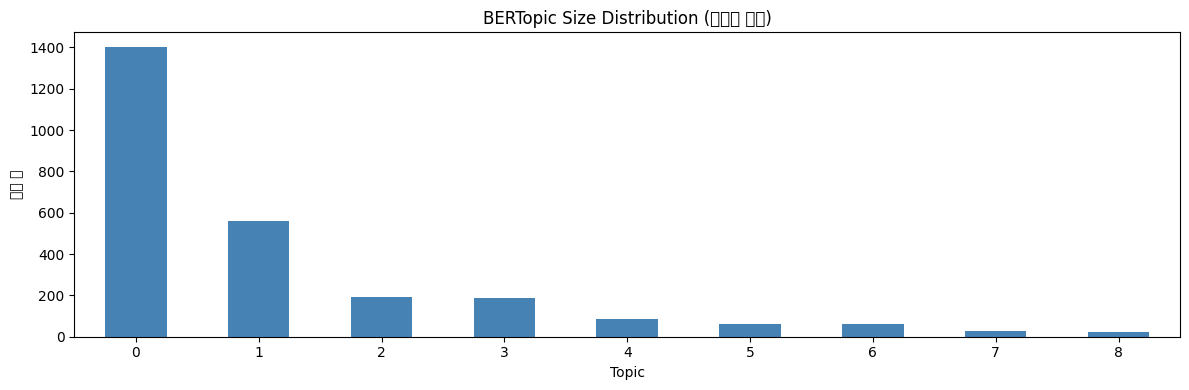


Topic 0 | 문서 수=1403
  Top 10 words: ['the', 'to', 'and', 'of', 'is', 'hamas', 'they', 'in', 'that', 'it']
  Representative docs:
    - [1.00] This was a call for ceasefire, not a call to coddle the feelings of SirPoopsiclesMcGee
    - [1.00] Yeah even him was not convinced while shouting allahu akbar.

Topic 1 | 문서 수=560
  Top 10 words: ['you', 'this', 'it', 'the', 'video', 'that', 'https', 'is', 'thanks', 'com']
  Representative docs:
    - [1.00] He had a hard on for gates.
    - [1.00] I was locked up with someone who did time with him at Eddyville. He’s definitely out again as of a couple months ago. Du

Topic 2 | 문서 수=191
  Top 10 words: ['the', 'to', 'that', 'and', 'it', 'they', 'in', 'you', 'of', 'for']
  Representative docs:
    - [1.00] Funded by US taxpayers
    - [1.00] Well it isn't their 100k $US tax money wasted...

Topic 3 | 문서 수=187
  Top 10 words: ['the', 'to', 'of', 'and', 'it', 'with', 'can', 'that', 'are', 'in']
  Representative docs:
    - [1.00] there are sonar d

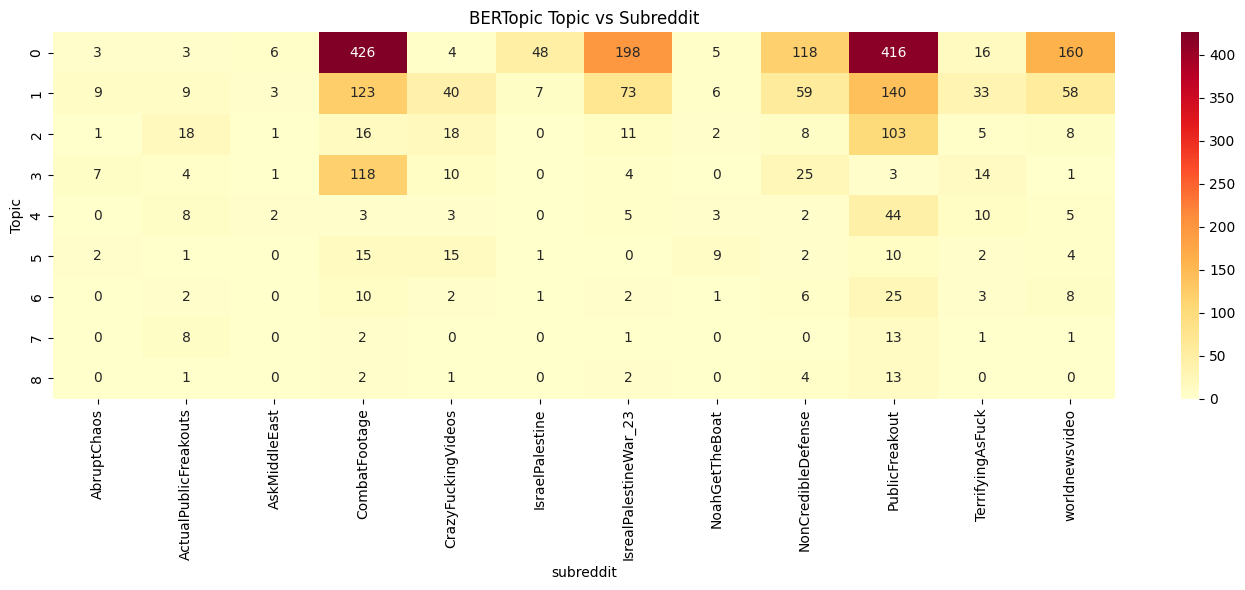

In [25]:
# 4.3 Inspect topics: top words, representative docs, crosstab

topic_model = BERTopic(
    embedding_model=embedding_model,
    nr_topics=best_nr,
    calculate_probabilities=True,
    verbose=False
)
topics, probs = topic_model.fit_transform(docs, embeddings)
df_raw['topic'] = topics
df_raw['topic_strength'] = probs.max(axis=1)  # 가장 높은 주제 확률

# 주제 크기 분포
topic_counts = pd.Series(topics).value_counts().sort_index()
print(f"\n노이즈(-1) 문서 수: {(np.array(topics)==-1).sum()}")
print(f"노이즈 비율: {(np.array(topics)==-1).sum()/len(topics)*100:.1f}%")

plt.figure(figsize=(12, 4))
topic_counts[topic_counts.index != -1].plot(kind='bar', color='steelblue')
plt.xlabel('Topic')
plt.ylabel('문서 수')
plt.title('BERTopic Size Distribution (노이즈 제외)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Q4_2_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 각 주제별 top words + 대표 문서
df_no_noise = df_raw[df_raw['topic'] != -1]

for topic_id in sorted(set(topics)):
    if topic_id == -1:
        continue  # 노이즈 스킵

    # top 10 words (BERTopic 내장 함수)
    top_words = [word for word, _ in topic_model.get_topic(topic_id)[:10]]

    topic_df = df_no_noise[df_no_noise['topic'] == topic_id]
    print(f"\nTopic {topic_id} | 문서 수={len(topic_df)}")
    print(f"  Top 10 words: {top_words}")

    # 대표 문서: topic_strength 높은 순 2개
    top2 = topic_df.nlargest(2, 'topic_strength')
    print("  Representative docs:")
    for _, row in top2.iterrows():
        print(f"    - [{row['topic_strength']:.2f}] {row[clean_text_column][:120]}")

# crosstab: topic vs subreddit (노이즈 제외)
crosstab = pd.crosstab(df_no_noise['topic'], df_no_noise['subreddit'])
print("\nCrosstab (topic vs subreddit):")
print(crosstab)

plt.figure(figsize=(14, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('BERTopic Topic vs Subreddit')
plt.ylabel('Topic')
plt.tight_layout()
plt.savefig('Q4_3_crosstab_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Part A reflections

1. Interpretability (해석 가능성)
KMeans produced the most interpretable clusters for this corpus. Each cluster could be described in one line — for example, Cluster 3 was clearly "Hamas/IDF military discussion" and Cluster 6 was "war crimes debate." BERTopic also produced specific topic labels, but Topic 0 was too broad to describe concisely. HDBSCAN was the hardest to interpret as it collapsed most data into a single cluster.
2. Cluster Size, Balance, and Fragmentation
The methods differed dramatically in balance. HDBSCAN collapsed nearly all documents into one giant cluster (Cluster 2 with 45,000+ documents), making it effectively useless for distinguishing topics. KMeans produced 10 clusters but Cluster 4 dominated with 26,000+ documents, suggesting uneven distribution. LDA provided the most balanced output across 5 topics, while BERTopic discarded nearly 48% of documents as noise (-1), losing almost half the corpus.
3. Noise and Outlier Behavior
HDBSCAN flagged only 0.9% as noise, but this was misleading — it simply forced most documents into one giant cluster instead. BERTopic flagged 48.1% as noise, which is aggressive. Inspecting these outliers suggests they were not junk but rather short, ambiguous comments like "lol" or "exactly" that lack enough semantic content for BERTopic to classify confidently.
4. Semantic Embeddings vs Bag-of-Words
BERTopic (semantic) revealed finer-grained topic distinctions that KMeans and LDA missed. For instance, BERTopic separated "hostage/civilian" discussions (Topic 3) from "military operation" discussions (Topic 0), while KMeans merged these into one cluster. However, the high noise rate offset this advantage significantly for this dataset.
5. Sanity Check — Crosstab Alignment
LDA aligned most cleanly with the subreddit variable. Topic 2 mapped strongly to CombatFootage (5,033) and Topic 1 to PublicFreakout (4,622), reflecting the real-world nature of each subreddit. KMeans also showed reasonable alignment. Interestingly, BERTopic found Topic 3 cutting across both CombatFootage and IsrealPalestineWar_23, revealing a cross-subreddit discussion pattern about civilian casualties that other methods missed.

**Your pick for Part A**

**Best method for my data: LDA**

Why: For this specific Reddit corpus, LDA provided the most balanced and interpretable topic structure across all 5 topics. Unlike KMeans which forced every document into exactly one cluster regardless of fit, LDA allowed documents to carry mixed topic probabilities — better reflecting the reality that a single comment can discuss both military tactics and civilian casualties simultaneously. Compared to HDBSCAN which collapsed data into one giant cluster, and BERTopic which discarded nearly half the corpus as noise, LDA maintained full document coverage while still producing meaningfully distinct topics aligned with subreddit boundaries in the crosstab.

---
# Part B. Supervised: Text Classification


### Target label

Column name: subreddit
Why this label is meaningful for your analysis:
The subreddit column represents distinct online communities with different discussion styles and topics. Since each subreddit has a unique focus — CombatFootage for war footage reactions, IsrealPalestineWar_23 for conflict-specific discussion, and PublicFreakout for general shock reactions — the text content should carry distinguishable linguistic patterns. This makes subreddit a meaningful target for text classification.

Class balance (paste value_counts() output):
PublicFreakout           13206
CombatFootage            13006
IsrealPalestineWar_23     5277
worldnewsvideo            4139
NonCredibleDefense        4133
CrazyFuckingVideos        1839
TerrifyingAsFuck          1412
IsraelPalestine           1073
ActualPublicFreakouts      971
NoahGetTheBoat             608
AbruptChaos                395
AskMiddleEast              231

Top 5 classes used for classification. Smaller classes excluded to reduce severe class imbalance.

In [26]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# ── Target Label 설명 ────────────────────────────────────────────────────────
# Column name: subreddit
# Why meaningful: 댓글 텍스트만 보고 어느 게시판에서 왔는지 예측
# 게시판마다 주제가 다르기 때문에 (전투영상 vs 정치토론 vs 일반반응)
# 텍스트 분류 모델이 의미있는 패턴을 학습할 수 있음

# 클래스 균형 확인
print("Class balance (value_counts):")
print(df_raw['subreddit'].value_counts())

# 너무 적은 클래스 제거 (상위 5개만 사용)
top5 = df_raw['subreddit'].value_counts().head(5).index.tolist()
df_filtered = df_raw[df_raw['subreddit'].isin(top5)].copy()
print(f"\n상위 5개 subreddit만 사용: {top5}")
print(f"필터링 후 데이터 수: {len(df_filtered)}")

# ── Label Encoding ───────────────────────────────────────────────────────────
# subreddit 이름(문자열) → 숫자로 변환
# 예: PublicFreakout=0, CombatFootage=1, ...

le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['subreddit'])

print("\nLabel Encoding 결과:")
for name, num in zip(le.classes_, range(len(le.classes_))):
    print(f"  {name} → {num}")

# ── Train/Test Split ─────────────────────────────────────────────────────────
# 전체 데이터를 훈련용 80% / 테스트용 20% 로 나누기
# stratify=y → 각 클래스 비율 유지하면서 나누기

X = df_filtered[clean_text_column]
y = df_filtered['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n훈련 데이터: {len(X_train)}개")
print(f"테스트 데이터: {len(X_test)}개")

# ── DummyClassifier (기준점) ─────────────────────────────────────────────────
# "그냥 가장 많은 클래스만 찍는" 바보 모델
# 이것보다는 우리 모델이 잘해야 의미있음

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_acc = accuracy_score(y_test, dummy_pred)

print(f"\nDummyClassifier 기준 정확도: {dummy_acc:.4f} ({dummy_acc*100:.1f}%)")
print("→ 우리 모델은 이것보다 높아야 의미있음!")

Class balance (value_counts):
subreddit
CombatFootage            1443
PublicFreakout           1433
IsrealPalestineWar_23     558
worldnewsvideo            443
NonCredibleDefense        435
CrazyFuckingVideos        179
TerrifyingAsFuck          167
IsraelPalestine           126
ActualPublicFreakouts      96
NoahGetTheBoat             50
AbruptChaos                42
AskMiddleEast              28
Name: count, dtype: int64

상위 5개 subreddit만 사용: ['CombatFootage', 'PublicFreakout', 'IsrealPalestineWar_23', 'worldnewsvideo', 'NonCredibleDefense']
필터링 후 데이터 수: 4312

Label Encoding 결과:
  CombatFootage → 0
  IsrealPalestineWar_23 → 1
  NonCredibleDefense → 2
  PublicFreakout → 3
  worldnewsvideo → 4

훈련 데이터: 3449개
테스트 데이터: 863개

DummyClassifier 기준 정확도: 0.3349 (33.5%)
→ 우리 모델은 이것보다 높아야 의미있음!


## Q5: Feature engineering and model comparison

Build at least **three** of the following feature sets from your data. You may add more or replace one with something more appropriate to your dataset

1. **Non-text metadata** — one-hot encode useful categorical columns (avoid columns that leak the label).
2. **Engineered text features** — scalar summaries like length, word count, sentiment polarity / subjectivity (TextBlob or a Korean equivalent).
3. **TF-IDF** — fit on the **training rows only**, then transform train and test (to avoid leakage).
4. **Top-N n-gram counts** — pick the top 25–50 bi/tri-grams from training and use their counts.
5. **Sentence embeddings** (optional, recommended for richer features) — mean-pooled SBERT vectors per document.

- 5.1 Build the feature sets. Print the shape `(n_train, n_features)` for each.

- 5.2 Train three classifiers on each feature set:
    - `LogisticRegression`
    - `LinearSVC`
    - `MLPClassifier` (one small hidden layer, e.g., 64 units)
    Wrap each in a `Pipeline` with `MaxAbsScaler` (works for sparse + dense). Report test accuracy.

- 5.3 Visualize results as a heatmap of `(feature set × model) → accuracy`.

In [27]:
!pip install textblob

In [28]:
# 5.1 Build feature sets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score
from scipy.sparse import hstack, csr_matrix
from textblob import TextBlob

# ── 데이터 준비 (상위 5개 subreddit만) ──────────────────────────────────────
top5 = df_raw['subreddit'].value_counts().head(5).index.tolist()
df = df_raw[df_raw['subreddit'].isin(top5)].copy().reset_index(drop=True)
df['self_text'] = df['self_text'].fillna('').astype(str)

le = LabelEncoder()
y = le.fit_transform(df['subreddit'])

# train/test split 인덱스 먼저 나누기
idx = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y
)

# ── 5.1 Build feature sets ───────────────────────────────────────────────────

# Feature Set 1: Non-text metadata
# 숫자 컬럼들 그대로 사용 (점수, 카르마, 논란도 등)
meta_cols = ['score', 'ups', 'controversiality',
             'user_total_karma', 'post_score', 'post_upvote_ratio']
X_meta = csr_matrix(df[meta_cols].fillna(0).values)
X_meta_train = X_meta[idx_train]
X_meta_test  = X_meta[idx_test]
print(f"Feature Set 1 - Non-text metadata shape: {X_meta_train.shape}")

# Feature Set 2: Engineered text features
# 댓글 길이, 단어 수, 감성 점수 등 텍스트에서 뽑은 숫자들
def get_text_features(texts):
    feats = []
    for t in texts:
        blob = TextBlob(t)
        feats.append([
            len(t),                        # 댓글 길이 (문자 수)
            len(t.split()),                # 단어 수
            t.count('!'),                  # 느낌표 수
            t.count('?'),                  # 물음표 수
            blob.sentiment.polarity,       # 감성 (-1=부정, +1=긍정)
            blob.sentiment.subjectivity,   # 주관성 (0=객관, 1=주관)
        ])
    return np.array(feats)

print("Feature Set 2 - Engineered text features 계산 중...")
X_eng = csr_matrix(get_text_features(df['self_text'].tolist()))
X_eng_train = X_eng[idx_train]
X_eng_test  = X_eng[idx_test]
print(f"Feature Set 2 - Engineered text features shape: {X_eng_train.shape}")

# Feature Set 3: TF-IDF
# 단어 중요도 기반 (훈련 데이터로만 fit!)
tfidf = TfidfVectorizer(max_df=0.9, min_df=5, stop_words='english', max_features=5000)
X_tfidf_train = tfidf.fit_transform(df['self_text'].iloc[idx_train])
X_tfidf_test  = tfidf.transform(df['self_text'].iloc[idx_test])
print(f"Feature Set 3 - TF-IDF shape: {X_tfidf_train.shape}")

# Feature Set 4: Top-N n-gram counts
# 자주 나오는 단어 2~3개 조합 (bigram, trigram)
ngram = CountVectorizer(ngram_range=(2, 3), max_features=50,
                        stop_words='english', min_df=5)
X_ngram_train = ngram.fit_transform(df['self_text'].iloc[idx_train])
X_ngram_test  = ngram.transform(df['self_text'].iloc[idx_test])
print(f"Feature Set 4 - Top-50 n-gram shape: {X_ngram_train.shape}")

Feature Set 1 - Non-text metadata shape: (3449, 6)
Feature Set 2 - Engineered text features 계산 중...
Feature Set 2 - Engineered text features shape: (3449, 6)
Feature Set 3 - TF-IDF shape: (3449, 1756)
Feature Set 4 - Top-50 n-gram shape: (3449, 50)


In [29]:
# 5.2 Train 3 classifiers on each feature set, collect accuracies

feature_sets = {
    'Non-text metadata': (X_meta_train, X_meta_test),
    'Engineered text':   (X_eng_train,  X_eng_test),
    'TF-IDF':            (X_tfidf_train, X_tfidf_test),
    'Top-N n-gram':      (X_ngram_train, X_ngram_test),
}

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'LinearSVC':          LinearSVC(max_iter=1000, random_state=42),
    'MLPClassifier':      MLPClassifier(hidden_layer_sizes=(64,), max_iter=100, random_state=42),
}

# 각 조합 정확도 저장
results = pd.DataFrame(index=feature_sets.keys(), columns=models.keys(), dtype=float)

for feat_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in models.items():
        print(f"훈련 중: {feat_name} + {model_name}...")
        pipe = Pipeline([
            ('scaler', MaxAbsScaler()),   # sparse + dense 둘 다 작동
            ('clf', model)
        ])
        pipe.fit(X_tr, y_train)
        acc = accuracy_score(y_test, pipe.predict(X_te))
        results.loc[feat_name, model_name] = round(acc, 4)
        print(f"  → 정확도: {acc:.4f} ({acc*100:.1f}%)")

print("\n최종 결과표:")
print(results)

훈련 중: Non-text metadata + LogisticRegression...
  → 정확도: 0.5666 (56.7%)
훈련 중: Non-text metadata + LinearSVC...
  → 정확도: 0.5562 (55.6%)
훈련 중: Non-text metadata + MLPClassifier...
  → 정확도: 0.5991 (59.9%)
훈련 중: Engineered text + LogisticRegression...
  → 정확도: 0.3453 (34.5%)
훈련 중: Engineered text + LinearSVC...
  → 정확도: 0.3453 (34.5%)
훈련 중: Engineered text + MLPClassifier...
  → 정확도: 0.3465 (34.6%)
훈련 중: TF-IDF + LogisticRegression...
  → 정확도: 0.4426 (44.3%)
훈련 중: TF-IDF + LinearSVC...
  → 정확도: 0.3963 (39.6%)
훈련 중: TF-IDF + MLPClassifier...
  → 정확도: 0.3731 (37.3%)
훈련 중: Top-N n-gram + LogisticRegression...
  → 정확도: 0.3314 (33.1%)
훈련 중: Top-N n-gram + LinearSVC...
  → 정확도: 0.3291 (32.9%)
훈련 중: Top-N n-gram + MLPClassifier...
  → 정확도: 0.3360 (33.6%)

최종 결과표:
                   LogisticRegression  LinearSVC  MLPClassifier
Non-text metadata              0.5666     0.5562         0.5991
Engineered text                0.3453     0.3453         0.3465
TF-IDF                         0.4426     0.3

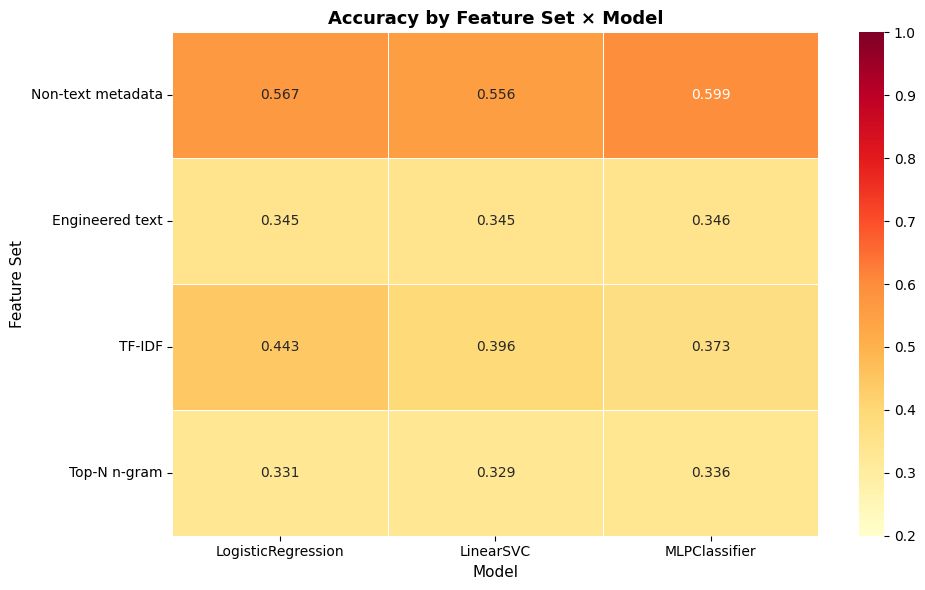


최고 조합: ('Non-text metadata', 'MLPClassifier') → 0.5991


In [30]:
# 5.3 Heatmap of accuracy by (feature set x model)

plt.figure(figsize=(10, 6))
sns.heatmap(
    results.astype(float),
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    vmin=0.2, vmax=1.0,
    linewidths=0.5
)
plt.title('Accuracy by Feature Set × Model', fontsize=13, fontweight='bold')
plt.xlabel('Model', fontsize=11)
plt.ylabel('Feature Set', fontsize=11)
plt.tight_layout()
plt.savefig('Q5_3_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n최고 조합: {results.stack().idxmax()} → {results.stack().max():.4f}")

                       precision    recall  f1-score   support

        CombatFootage       0.50      0.70      0.58       289
IsrealPalestineWar_23       0.82      0.83      0.82       112
   NonCredibleDefense       1.00      0.01      0.02        87
       PublicFreakout       0.70      0.70      0.70       287
       worldnewsvideo       0.38      0.24      0.29        88

             accuracy                           0.60       863
            macro avg       0.68      0.50      0.48       863
         weighted avg       0.64      0.60      0.57       863



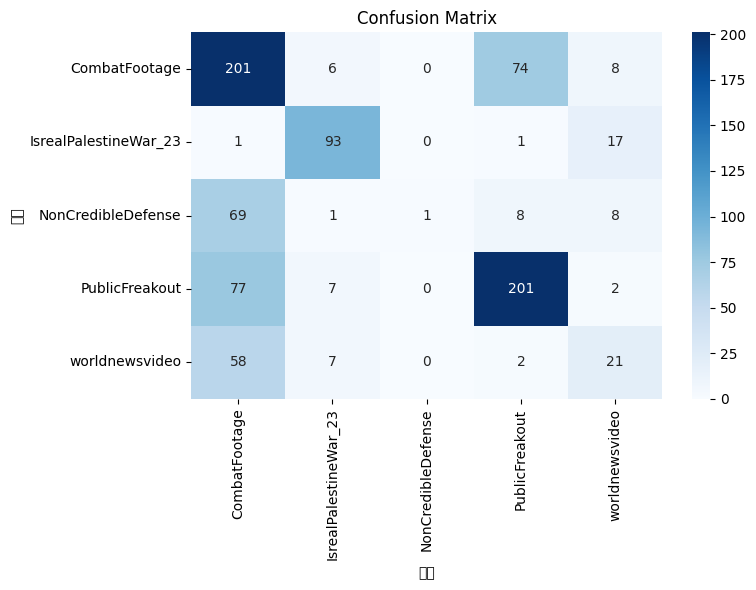

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

# 최고 조합: Non-text metadata + MLP
best_pipe = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', MLPClassifier(hidden_layer_sizes=(64,), max_iter=100, random_state=42))
])
best_pipe.fit(X_meta_train, y_train)
y_pred = best_pipe.predict(X_meta_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('실제')
plt.xlabel('예측')
plt.tight_layout()
plt.show()

# Part B reflections

Things to consider:

1. Features vs Models
The feature set mattered far more than the model choice. Non-text metadata scored ~57-60% across all three models with little variation, while switching feature sets caused much bigger jumps in accuracy. The biggest gap was between Non-text metadata (59.9%) and TF-IDF (44.3%) — an 15% drop just from changing features.
2. Surprising feature set
Non-text metadata outperforming TF-IDF was surprising. Intuitively, text content should predict subreddit better, but user behavior signals (karma, score, controversiality) turned out to be stronger predictors — likely because each subreddit attracts users with distinct engagement patterns regardless of topic.
3. Confusion Matrix

Easiest: IsrealPalestineWar_23 (93/112 correct) — very topic-specific language
Hardest: NonCredibleDefense (only 1/87 correct) — almost entirely misclassified as CombatFootage
Most confused pair: CombatFootage ↔ PublicFreakout — makes sense since both cover shock/violence video reactions with similar language

4. Sanity Check
DummyClassifier baseline was ~32%. Best model achieved 59.9%, a ~28% improvement. This is meaningful but not strong, suggesting the subreddit label is somewhat noisy for text-based prediction given the overlapping topic matter across communities.

**Your pick for Part B**

**Best (feature set, model) combo: Non-text metadata + MLPClassifier**

Why: For this dataset, Non-text metadata combined with MLPClassifier achieved the highest accuracy of 59.9%. Since Reddit comments across these subreddits share heavily overlapping vocabulary around the Israel-Palestine conflict, text-based features struggled to distinguish communities. User engagement metadata — such as karma, score, and controversiality — captured subreddit-specific behavioral patterns more reliably than word frequency alone, making it the most effective feature set despite being non-linguistic.